# 🎯 Actionability Classification - Training

- **Implemented**: Đã triển khai / có kết quả / có số liệu
- **Planning**: Kế hoạch / mục tiêu tương lai
- **Indeterminate**: Cam kết chung chung, không rõ hành động

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
TRAIN_PATH = Path("action_hybrid_train_split.parquet")
VAL_PATH = Path("action_hybrid_val_split.parquet")
GOLD_PATH = Path("action_gold.parquet")
OUTPUT_DIR = Path("outputs/models/esg_action")

# Model
MODEL_NAME = "vinai/phobert-large"
LABELS = ["Implemented", "Planning", "Indeterminate"]
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}

# Block types that should use context
CONTEXT_BLOCK_TYPES = {"paragraph", "bullet_like", "kpi_like"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1️⃣ Load Data

In [2]:
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
gold_df = pd.read_parquet(GOLD_PATH) if GOLD_PATH.exists() else None

print(f"Train: {len(train_df):,}")
print(f"Val: {len(val_df):,}")
print(f"Gold: {len(gold_df):,}" if gold_df is not None else "Gold: Not available")

print("\n=== TRAIN DISTRIBUTION ===")
print(train_df["final_action"].value_counts())
print(f"\nImbalance ratio: {train_df['final_action'].value_counts().max() / train_df['final_action'].value_counts().min():.1f}x")

Train: 5,097
Val: 900
Gold: 498

=== TRAIN DISTRIBUTION ===
final_action
Indeterminate    3064
Implemented      1867
Planning          166
Name: count, dtype: int64

Imbalance ratio: 18.5x


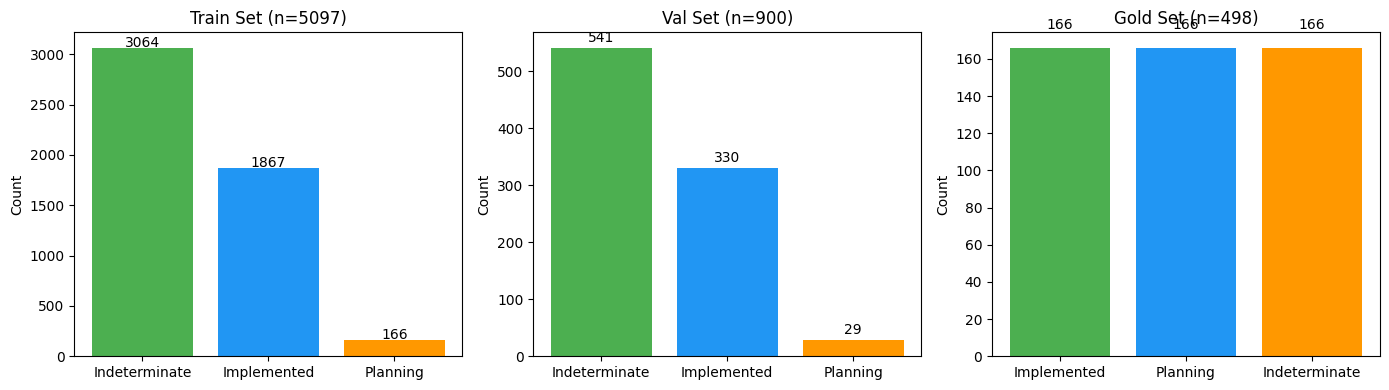

In [3]:
# Visualize distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df) in zip(axes, [("Train", train_df), ("Val", val_df), ("Gold", gold_df)]):
    if df is not None:
        col = "final_action" if "final_action" in df.columns else "gold_action"
        counts = df[col].value_counts()
        colors = ["#4CAF50", "#2196F3", "#FF9800"]  # Implemented=green, Planning=blue, Indeterminate=orange
        ax.bar(counts.index, counts.values, color=colors)
        ax.set_title(f"{name} Set (n={len(df)})")
        ax.set_ylabel("Count")
        for i, v in enumerate(counts.values):
            ax.text(i, v + 10, str(v), ha="center")

plt.tight_layout()
plt.show()

## 2️⃣ Compute Class Weights

In [4]:
labels_array = train_df["final_action"].map(LABEL2ID).values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=labels_array
)

print("Class Weights:")
for label, weight in zip(LABELS, class_weights):
    print(f"  {label}: {weight:.4f}")

Class Weights:
  Implemented: 0.9100
  Planning: 10.2349
  Indeterminate: 0.5545


## 3️⃣ Dataset & Tokenizer

In [5]:
class ActionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 256, use_context: bool = True):
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Prepare texts with context for paragraph/bullet, sentence only for table
        self.texts = []
        for _, row in df.iterrows():
            if use_context and row.get("block_type", "") in CONTEXT_BLOCK_TYPES:
                parts = []
                if row.get("ctx_prev"):
                    parts.append(str(row["ctx_prev"]))
                parts.append(str(row["sentence"]))
                if row.get("ctx_next"):
                    parts.append(str(row["ctx_next"]))
                text = " ".join(parts)
            else:
                text = str(row["sentence"])
            self.texts.append(text)

        label_col = "final_action" if "final_action" in df.columns else "gold_action"
        self.labels = [LABEL2ID[label] for label in df[label_col]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [6]:
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

# Create datasets
MAX_LENGTH = 256
USE_CONTEXT = True

train_dataset = ActionDataset(train_df, tokenizer, MAX_LENGTH, USE_CONTEXT)
val_dataset = ActionDataset(val_df, tokenizer, MAX_LENGTH, USE_CONTEXT)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset: {len(val_dataset)}")
print(f"\nSample text (with context):")
print(train_dataset.texts[0][:200] + "...")

Loading tokenizer: vinai/phobert-large


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train dataset: 5097
Val dataset: 900

Sample text (with context):
Đặc biệt, với từng khách hàng, SHB không những hỗ trợ nguồn tài chính mà còn đồng hành với khách hàng từ khâu xây dựng kế hoạch, phương án kinh doanh đến cung ứng các gói sản phẩm toàn diện gồm tiền g...


## 4️⃣ Model & Trainer

In [7]:
class WeightedTrainer(Trainer):
    """Custom Trainer with class weights for imbalanced data"""

    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            weight = torch.tensor(self.class_weights, device=logits.device, dtype=logits.dtype)
            loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
        else:
            loss_fct = torch.nn.CrossEntropyLoss()

        loss = loss_fct(logits.view(-1, len(LABELS)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    per_class_f1 = f1_score(labels, predictions, average=None)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "f1_implemented": per_class_f1[0],
        "f1_planning": per_class_f1[1],
        "f1_indeterminate": per_class_f1[2],
    }

In [8]:
print(f"Loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

print(f"Model parameters: {model.num_parameters():,}")

Loading model: vinai/phobert-large


pytorch_model.bin:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model parameters: 369,166,339


In [9]:
# Training arguments
EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE = 2e-5

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir=str(OUTPUT_DIR / "logs"),
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer ready!")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Class weights: enabled")

Trainer ready!
  Epochs: 5
  Batch size: 16
  Learning rate: 2e-05
  Class weights: enabled


## 5️⃣ Train!

In [10]:
print("🚀 Starting training...")
trainer.train()

🚀 Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,F1 Implemented,F1 Planning,F1 Indeterminate
1,0.942300,0.630487,0.745556,0.690163,0.729560,0.567568,0.773362
2,0.625500,0.871479,0.804444,0.694213,0.764205,0.470588,0.847847


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,F1 Implemented,F1 Planning,F1 Indeterminate
1,0.942300,0.630487,0.745556,0.690163,0.729560,0.567568,0.773362
2,0.625500,0.871479,0.804444,0.694213,0.764205,0.470588,0.847847
3,0.466900,0.757957,0.820000,0.714071,0.777948,0.500000,0.864266
4,0.327000,0.886067,0.838889,0.733815,0.808321,0.516129,0.876995
5,0.185500,0.974297,0.831111,0.725133,0.809182,0.500000,0.866218


TrainOutput(global_step=1595, training_loss=0.5409052600681221, metrics={'train_runtime': 1643.4056, 'train_samples_per_second': 15.507, 'train_steps_per_second': 0.971, 'total_flos': 1.187517552079104e+16, 'train_loss': 0.5409052600681221, 'epoch': 5.0})

## 6️⃣ Evaluation

In [11]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def evaluate_and_report(dataset, df, name="Validation"):
    print(f"\n{'='*60}")
    print(f"{name.upper()} RESULTS")
    print("="*60)

    predictions = trainer.predict(dataset)
    preds = np.argmax(predictions.predictions, axis=-1)

    label_col = "final_action" if "final_action" in df.columns else "gold_action"
    labels = [LABEL2ID[l] for l in df[label_col]]

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=LABELS))

    plot_confusion_matrix(labels, preds, f"{name} Confusion Matrix")

    return {"accuracy": acc, "macro_f1": macro_f1}


VALIDATION RESULTS


Accuracy: 0.8389
Macro-F1: 0.7338

Classification Report:
               precision    recall  f1-score   support

  Implemented       0.79      0.82      0.81       330
     Planning       0.48      0.55      0.52        29
Indeterminate       0.89      0.86      0.88       541

     accuracy                           0.84       900
    macro avg       0.72      0.75      0.73       900
 weighted avg       0.84      0.84      0.84       900



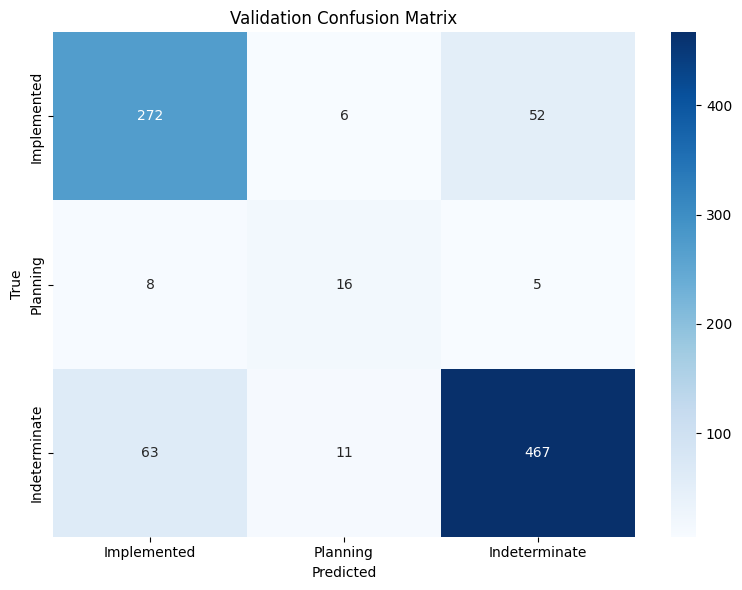

In [12]:
# Validation evaluation
val_results = evaluate_and_report(val_dataset, val_df, "Validation")


GOLD SET RESULTS


Accuracy: 0.9157
Macro-F1: 0.9156

Classification Report:
               precision    recall  f1-score   support

  Implemented       0.88      0.95      0.92       166
     Planning       1.00      0.84      0.92       166
Indeterminate       0.88      0.95      0.92       166

     accuracy                           0.92       498
    macro avg       0.92      0.92      0.92       498
 weighted avg       0.92      0.92      0.92       498



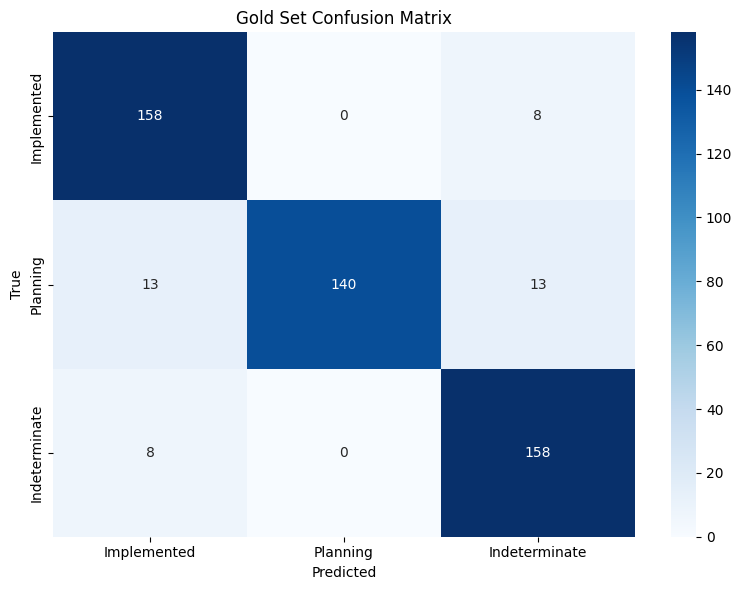

In [13]:
# Gold set evaluation
if gold_df is not None:
    gold_df_eval = gold_df.copy()
    gold_df_eval["final_action"] = gold_df_eval["gold_action"]
    gold_dataset = ActionDataset(gold_df_eval, tokenizer, MAX_LENGTH, USE_CONTEXT)
    gold_results = evaluate_and_report(gold_dataset, gold_df_eval, "Gold Set")

## 7️⃣ Save Model

In [14]:
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"✅ Model saved to: {OUTPUT_DIR}")
print(f"\nTo load the model:")
print(f"  tokenizer = AutoTokenizer.from_pretrained('{OUTPUT_DIR}')")
print(f"  model = AutoModelForSequenceClassification.from_pretrained('{OUTPUT_DIR}')")

✅ Model saved to: outputs/models/esg_action

To load the model:
  tokenizer = AutoTokenizer.from_pretrained('outputs/models/esg_action')
  model = AutoModelForSequenceClassification.from_pretrained('outputs/models/esg_action')


## 8️⃣ Quick Inference Test

In [15]:
def predict(text: str) -> dict:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.to(device)
    model.eval()

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0]
        pred_idx = torch.argmax(probs).item()

    return {
        "label": LABELS[pred_idx],
        "confidence": probs[pred_idx].item(),
        "all_probs": {l: p.item() for l, p in zip(LABELS, probs)}
    }

# Test examples
test_sentences = [
    "Năm 2023, Ngân hàng đã giảm 15% lượng khí thải CO2.",
    "Ngân hàng đặt mục tiêu trung hòa carbon vào năm 2050.",
    "Ngân hàng cam kết phát triển bền vững và bảo vệ môi trường.",
]

print("=== INFERENCE TEST ===")
for sent in test_sentences:
    result = predict(sent)
    print(f"\n📝 {sent}")
    print(f"   → {result['label']} ({result['confidence']:.2%})")

=== INFERENCE TEST ===

📝 Năm 2023, Ngân hàng đã giảm 15% lượng khí thải CO2.
   → Implemented (98.66%)

📝 Ngân hàng đặt mục tiêu trung hòa carbon vào năm 2050.
   → Planning (99.55%)

📝 Ngân hàng cam kết phát triển bền vững và bảo vệ môi trường.
   → Indeterminate (99.48%)


## 📊 Summary

### Results

In [16]:
print("="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Model: {MODEL_NAME}")
print(f"Train samples: {len(train_df):,}")
print(f"Val samples: {len(val_df):,}")
print(f"Epochs: {EPOCHS}")
print(f"Class weights: Yes")
print(f"Context: {USE_CONTEXT}")
print(f"\nValidation Macro-F1: {val_results['macro_f1']:.4f}")
if gold_df is not None:
    print(f"Gold Set Macro-F1: {gold_results['macro_f1']:.4f}")
print(f"\nModel saved: {OUTPUT_DIR}")

TRAINING SUMMARY
Model: vinai/phobert-large
Train samples: 5,097
Val samples: 900
Epochs: 5
Class weights: Yes
Context: True

Validation Macro-F1: 0.7338
Gold Set Macro-F1: 0.9156

Model saved: outputs/models/esg_action


In [17]:
# Config for HuggingFace Hub
HF_REPO_NAME = "esg-action"
HF_USERNAME = "huypham71"

# Model card info
MODEL_CARD_INFO = {
    "language": "vi",
    "license": "mit",
    "library_name": "transformers",
    "pipeline_tag": "text-classification",
    "tags": [
        "esg",
        "esg-washing",
        "actionability",
        "banking",
        "vietnamese",
        "nlp",
        "sustainability"
    ],
}

In [18]:
from huggingface_hub import login, HfApi, whoami

try:
    user_info = whoami()
    HF_USERNAME = user_info["name"]
    print(f"✅ Already logged in as: {HF_USERNAME}")
except Exception:
    print("🔐 Please login to HuggingFace Hub...")
    print("   You can get your token from: https://huggingface.co/settings/tokens")
    login()
    user_info = whoami()
    HF_USERNAME = user_info["name"]
    print(f"✅ Logged in as: {HF_USERNAME}")

✅ Already logged in as: huypham71


In [19]:
# Create model card content
model_card_content = f"""
---
language: vi
license: mit
library_name: transformers
pipeline_tag: text-classification
tags:
- esg
- esg-washing
- actionability
- banking
- vietnamese
- nlp
- sustainability
---

# ESG Actionability Classifier for Vietnamese Banking Reports

## Model description
This model is a Vietnamese text classification model fine-tuned from **PhoBERT-large** to classify **ESG-related sentences** in banking annual reports according to their **actionability level**.

The model is designed as **Module 3 (Actionability Classification)** in a multi-stage ESG-washing analysis framework. It does **not** assess factual correctness or ESG performance, but focuses on identifying whether a disclosure describes concrete actions, future plans, or vague commitments.

The model predicts one of three labels:
- **Implemented**: concrete actions or achieved results (often with time references or quantitative indicators)
- **Planning**: stated plans, targets, or future-oriented commitments
- **Indeterminate**: general or symbolic statements without specific actions or evidence

---

## Intended use

### Primary intended use
- Analyzing ESG disclosure quality in Vietnamese banking annual reports.
- Supporting ESG-washing risk analysis by distinguishing substantive actions from symbolic language.

### Example downstream usage
- Measuring the proportion of *Implemented* vs. *Indeterminate* ESG statements at the bank-year level.
- Serving as an intermediate module before evidence linking and ESG-washing risk scoring.

### Out-of-scope use
- Determining the factual truthfulness of ESG claims.
- Legal, regulatory, or investment decision-making without human review.
- Application to non-banking or non-Vietnamese text without re-validation.

---

## Training data

The model was trained using a **hybrid labeling strategy**:
- **LLM-generated labels** as a semantic teacher for actionability
- **Weak labeling rules** based on linguistic and domain-specific patterns (e.g., time references, quantitative indicators)
- A **pseudo-gold set** sampled from high-confidence LLM labels for calibration and evaluation

Training/validation data:
- Total labeled samples: **5,997**
- Train set: **5,097**
- Validation set: **900**

Label distribution (train):
- Implemented: ~37%
- Planning: ~3%
- Indeterminate: ~60%

Class imbalance was handled using **class-weighted loss** during training.

---

## Training procedure
- Base model: **PhoBERT-large**
- Task: 3-class sentence-level classification
- Loss: Cross-entropy with class weights
- Evaluation metric: **Macro-F1**
- Input representation:
  - Narrative text: sentence with local context (previous + next sentence)
  - Tables/KPI-like text: sentence only

---

## Evaluation results

### Validation set (900 samples)
- Accuracy: **0.839**
- Macro-F1: **0.734**

Per-class (validation):

| Label | Precision | Recall | F1 |
|------|-----------|--------|----|
| Implemented | 0.79 | 0.82 | 0.81 |
| Planning | 0.48 | 0.55 | 0.52 |
| Indeterminate | 0.89 | 0.86 | 0.88 |

### Pseudo-gold test set (498 samples, balanced)
- Accuracy: **0.916**
- Macro-F1: **0.916**

> Note: The pseudo-gold set is derived from high-confidence LLM labels and is balanced across classes. It may not fully reflect real-world class distributions.

---

## How to use

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_id = "{HF_USERNAME}/{HF_REPO_NAME}"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id)

labels = ["Implemented", "Planning", "Indeterminate"]

text = "Năm 2023, ngân hàng đã giảm 15% lượng khí thải CO2."
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)

with torch.no_grad():
    logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()

pred = labels[int(probs.argmax())]
print(pred, float(probs.max()))
```

---

## Limitations

The model captures linguistic actionability, not actual ESG performance.

Planning statements are relatively rare, which may affect robustness on unseen corpora.

Performance may degrade on domains outside Vietnamese banking reports.

## Ethical considerations

Outputs should be interpreted as analytical signals, not definitive judgments.

Automated classification may reflect biases present in disclosure styles or training data.

"""
# Save model card
model_card_path = OUTPUT_DIR / "README.md"
with open(model_card_path, "w", encoding="utf-8") as f:
    f.write(model_card_content)

print(f"📝 Model card saved: {model_card_path}")
print(f"   Preview (first 500 chars):\n")
print(model_card_content[:500] + "...")

📝 Model card saved: outputs/models/esg_action/README.md
   Preview (first 500 chars):


---
language: vi
license: mit
library_name: transformers
pipeline_tag: text-classification
tags:
- esg
- esg-washing
- actionability
- banking
- vietnamese
- nlp
- sustainability
---

# ESG Actionability Classifier for Vietnamese Banking Reports

## Model description
This model is a Vietnamese text classification model fine-tuned from **PhoBERT-large** to classify **ESG-related sentences** in banking annual reports according to their **actionability level**.

The model is designed as **Module 3...


In [20]:
# Push model to HuggingFace Hub
from huggingface_hub import HfApi

api = HfApi()
repo_id = f"{HF_USERNAME}/{HF_REPO_NAME}"

print(f"🚀 Pushing model to: https://huggingface.co/{repo_id}")

# Create repo if not exists and upload
api.create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True,
    private=False,  # Set to True if you want private repo
)

# Upload all files in OUT_DIR
api.upload_folder(
    folder_path=OUTPUT_DIR,
    repo_id=repo_id,
    repo_type="model",
    commit_message=f"Upload ESG Action",
)

print(f"\n✅ Model pushed successfully!")
print(f"   🔗 https://huggingface.co/{repo_id}")

🚀 Pushing model to: https://huggingface.co/huypham71/esg-action


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...kpoint-1595/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...kpoint-1276/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

...

  ...nt-1276/model.safetensors:   0%|          |  758kB / 1.48GB            

  ..._action/model.safetensors:   0%|          | 6.14MB / 1.48GB            

  ...eckpoint-319/optimizer.pt:   0%|          | 14.1MB / 2.95GB            

  ...nt-1595/model.safetensors:   0%|          |  558kB / 1.48GB            


✅ Model pushed successfully!
   🔗 https://huggingface.co/huypham71/esg-action
